In [1]:
import wandb

import pandas as pd

from tqdm import tqdm

from matplotlib import pyplot as plt

import numpy as np 

from xaikd import models, datasets

from torch.utils.data import DataLoader
from xaikd.utils import metrics

In [120]:
api = wandb.Api()

In [3]:
EXPERIMENT_GROUP = "./artifacts/2023-09-s14/distill-layerwise/run1/distill"

In [141]:
def read_data(
    teacher,
    student,
    policy,
    lambda_task,
    lambda_kd,
    arr_training_sizes,
    arr_contamination_levels,
    verbose=False,
    
):
    
    
    runs = api.runs(
        f'p16i/xaikd-distillation-layerwise-ep2',
        {
        "$and": [
            {"group": EXPERIMENT_GROUP},
            {"config.teacher": teacher},
            {"config.student": student},
            {"config.lambda_task": lambda_task},
            {"config.lambda_kd": lambda_kd},
            {"config.policy": policy},
            {"config.training_size": {"$in": arr_training_sizes}},
            {"config.contamination_level": {"$in": arr_contamination_levels}},
        ]}
    )
    
    if verbose:
        print(f"we have {len(runs)} runs")
    
    rows = []
    
    for run in runs:
        seed = run.config["seed"]
         
        k = np.argmax(run.summary["arr_metrics"]["val_acc"])
        best_val_acc = run.summary["arr_metrics"]["val_acc"][k]
        best_val_agreement = run.summary["arr_metrics"]["val_agreement"][k]
        best_val_agreement_on_teacher_correct = run.summary["arr_metrics"]["val_agreement_on_teacher_correct"][k]


        rows.append(
            dict(
                best_epoch=k,
                seed=seed, 
                lambda_task=run.config["lambda_task"],
                lambda_kd=run.config["lambda_kd"],
                lambda_layer=run.config["policy_lambda_layer"],
                training_size=run.config["training_size"],
                contamination_level=run.config["contamination_level"],

                val_acc=best_val_acc, 
                val_agreement=best_val_agreement,
                val_agreement_on_teacher_correct=best_val_agreement_on_teacher_correct,
                teacher_acc=run.summary["teacher_acc"],
            )
        )

    
    
    
    df = pd.DataFrame(rows)

      
    df = df.groupby(by=["training_size", "contamination_level"]).agg(
        {
            "val_acc": ["mean", "std", "count"],
            "val_agreement": ["mean", "std", "count"],
            "val_agreement_on_teacher_correct": ["mean", "std", "count"],
            "teacher_acc": ["mean"]
        }
    ).reset_index()
    
    np.testing.assert_allclose(
        df["val_acc"]["count"].values,
        20,
        err_msg="number of count should eqalt to the number of CIFAR100 superclasses"
    )

    if verbose:
        print(f"df.shape: {df.shape}")
    return df

summary = read_data(
    teacher="cifar100-resnet18-v1",
    student="resnet18cifarcompr2",

    policy="basis-identity:pca--uncentered",
    arr_training_sizes=[1.0, 0.5, 0.25, 0.1],
    arr_contamination_levels=[0.0, 0.25, 0.5, 0.75],
    
    lambda_task=0.0,
    lambda_kd=1.0,
    
    verbose=True,
)

summary

we have 320 runs
df.shape: (16, 12)


training_size contamination_level val_acc                 val_agreement  \
                                        mean       std count          mean   
0           0.10                0.00  0.6967  0.104990    20        0.7017   
1           0.10                0.25  0.6858  0.099216    20        0.6940   
2           0.10                0.50  0.6230  0.112301    20        0.6301   
3           0.10                0.75  0.5338  0.119699    20        0.5390   
4           0.25                0.00  0.7769  0.100224    20        0.7823   
5           0.25                0.25  0.7640  0.099555    20        0.7686   
6           0.25                0.50  0.6894  0.113258    20        0.7000   
7           0.25                0.75  0.5972  0.126270    20        0.6074   
8           0.50                0.00  0.8145  0.085780    20        0.8189   
9           0.50                0.25  0.7957  0.088917    20        0.8015   
10          0.50                0.50  0.7335  0.115463    20        0.7439   
11          0.50                0.75  0.6289  0.129606    20        0.6370   
12          1.00                0.00  0.8519  0.075275    20        0.8614   
13          1.00                0.25  0.8302  0.084781    20        0.8405   
14          1.00                0.50  0.7782  0.103381    20        0.7934   
15          1.00                0.75  0.6929  0.125320    20        0.7050   

                   val_agreement_on_teacher_correct                  \
         std count                             mean       std count   
0   0.103412    20                           0.6540  0.123042    20   
1   0.095833    20                           0.6421  0.114672    20   
2   0.108567    20                           0.5802  0.125362    20   
3   0.118000    20                           0.4923  0.126173    20   
4   0.101066    20                           0.7301  0.122839    20   
5   0.098134    20                           0.7152  0.120118    20   
6   0.109402    20                           0.6473  0.129152    20   
7   0.120906    20                           0.5579  0.134494    20   
8   0.082384    20                           0.7652  0.109033    20   
9   0.085660    20                           0.7458  0.111281    20   
10  0.106462    20                           0.6896  0.127958    20   
11  0.121197    20                           0.5885  0.138113    20   
12  0.066266    20                           0.8023  0.098225    20   
13  0.073944    20                           0.7794  0.104215    20   
14  0.087431    20                           0.7346  0.116124    20   
15  0.110575    20                           0.6506  0.135417    20   

   teacher_acc  
          mean  
0       0.8677  
1       0.8608  
2       0.8556  
3       0.8498  
4       0.8677  
5       0.8608  
6       0.8556  
7       0.8497  
8       0.8677  
9       0.8608  
10      0.8556  
11      0.8498  
12      0.8677  
13      0.8608  
14      0.8556  
15      0.8498

In [133]:
0.125320 / (20**0.5)

0.02802240389402736

In [23]:
read_data(
    teacher="cifar100-resnet18-v1",
    student="resnet18cifarcompr2",

    policy="basis-identity:prca-sortabs--uncentered",
    arr_training_sizes=[1.0, 0.5, 0.25, 0.1],
    arr_contamination_levels=[0.0, 0.25, 0.5, 0.75],
    
    lambda_task=0.0,
    lambda_kd=1.0,
    
    verbose=True,
)


we have 320 runs
df.shape: (16, 12)


training_size contamination_level val_acc                 val_agreement  \
                                        mean       std count          mean   
0           0.10                0.00  0.6958  0.102909    20        0.6989   
1           0.10                0.25  0.6861  0.103859    20        0.6928   
2           0.10                0.50  0.6236  0.106837    20        0.6274   
3           0.10                0.75  0.5251  0.121459    20        0.5350   
4           0.25                0.00  0.7750  0.102148    20        0.7807   
5           0.25                0.25  0.7655  0.098506    20        0.7640   
6           0.25                0.50  0.7053  0.113656    20        0.7117   
7           0.25                0.75  0.6046  0.121427    20        0.6168   
8           0.50                0.00  0.8155  0.088382    20        0.8213   
9           0.50                0.25  0.7962  0.094653    20        0.8033   
10          0.50                0.50  0.7414  0.104402    20        0.7552   
11          0.50                0.75  0.6426  0.127649    20        0.6552   
12          1.00                0.00  0.8566  0.076442    20        0.8655   
13          1.00                0.25  0.8346  0.086482    20        0.8450   
14          1.00                0.50  0.7760  0.101274    20        0.7908   
15          1.00                0.75  0.6926  0.126315    20        0.7056   

                   val_agreement_on_teacher_correct                  \
         std count                             mean       std count   
0   0.102268    20                           0.6522  0.121413    20   
1   0.101420    20                           0.6420  0.122058    20   
2   0.101979    20                           0.5804  0.120713    20   
3   0.116744    20                           0.4878  0.127804    20   
4   0.098793    20                           0.7289  0.122336    20   
5   0.100604    20                           0.7132  0.122688    20   
6   0.107864    20                           0.6587  0.130226    20   
7   0.117800    20                           0.5672  0.129734    20   
8   0.084023    20                           0.7667  0.109641    20   
9   0.086341    20                           0.7466  0.114160    20   
10  0.096889    20                           0.6988  0.118825    20   
11  0.120784    20                           0.6036  0.136326    20   
12  0.067268    20                           0.8060  0.100768    20   
13  0.073766    20                           0.7838  0.106261    20   
14  0.085324    20                           0.7316  0.116161    20   
15  0.114032    20                           0.6520  0.135144    20   

   teacher_acc  
          mean  
0       0.8677  
1       0.8608  
2       0.8556  
3       0.8498  
4       0.8677  
5       0.8608  
6       0.8556  
7       0.8498  
8       0.8677  
9       0.8608  
10      0.8556  
11      0.8498  
12      0.8677  
13      0.8608  
14      0.8556  
15      0.8498

In [140]:
def read_data_baseline(
    teacher,
    student,
    lambda_task,
    lambda_kd,
    training_size,
    arr_contamination_levels,
    verbose=False,
    
):
    runs = api.runs(
        f'p16i/xaikd-distillation-layerwise-ep2',
        {
        "$and": [
            {"group": EXPERIMENT_GROUP + "-baselinerun"},
            {"config.teacher": teacher},
            {"config.student": student},
            {"config.lambda_task": lambda_task},
            {"config.lambda_kd": lambda_kd},
            {"config.policy": "basis-identity:random--uncentered"},
            {"config.training_size": training_size},
            {"config.contamination_level": {"$in": arr_contamination_levels}},
        ]}
    )
    
    if verbose:
        print(f"we have {len(runs)} runs")
    
    rows = []
    
    for run in runs:
        seed = run.config["seed"]
         
        k = np.argmax(run.summary["arr_metrics"]["val_acc"])
        best_val_acc = run.summary["arr_metrics"]["val_acc"][k]
        best_val_agreement = run.summary["arr_metrics"]["val_agreement"][k]
        best_val_agreement_on_teacher_correct = run.summary["arr_metrics"]["val_agreement_on_teacher_correct"][k]

        assert run.config["lambda_layer"] is not None

        rows.append(
            dict(
                best_epoch=k,
                seed=seed, 
                lambda_task=run.config["lambda_task"],
                lambda_kd=run.config["lambda_kd"],
                lambda_layer=run.config["policy_lambda_layer"],
                training_size=run.config["training_size"],
                contamination_level=run.config["contamination_level"],

                val_acc=best_val_acc, 
                val_agreement=best_val_agreement,
                val_agreement_on_teacher_correct=best_val_agreement_on_teacher_correct,
                teacher_acc=run.summary["teacher_acc"],
            )
        )

    
    
    
    df = pd.DataFrame(rows)

      
    df = df.groupby(by=["training_size", "contamination_level"]).agg(
        {
            "val_acc": ["mean", "std", "count"],
            "val_agreement": ["mean", "std", "count"],
            "val_agreement_on_teacher_correct": ["mean", "std", "count"],
            "teacher_acc": ["mean"]
        }
    ).reset_index()
    
    np.testing.assert_allclose(
        df["val_acc"]["count"].values,
        20,
        err_msg="number of count should eqalt to the number of CIFAR100 superclasses"
    )

    if verbose:
        print(f"df.shape: {df.shape}")
    return df

read_data_baseline(
    teacher="cifar100-resnet18-v1",
    student="resnet18cifarcompr2",
    training_size=1.0,
    arr_contamination_levels=[0.0],
    lambda_task=0.0,
    lambda_kd=1.0
)

training_size contamination_level val_acc                 val_agreement  \
                                       mean       std count          mean   
0             1                   0  0.8006  0.091066    20        0.7984   

                  val_agreement_on_teacher_correct                 teacher_acc  
        std count                             mean       std count        mean  
0  0.089192    20                           0.7486  0.112671    20      0.8677

# Comparison on `training-size` and `contamination-level`

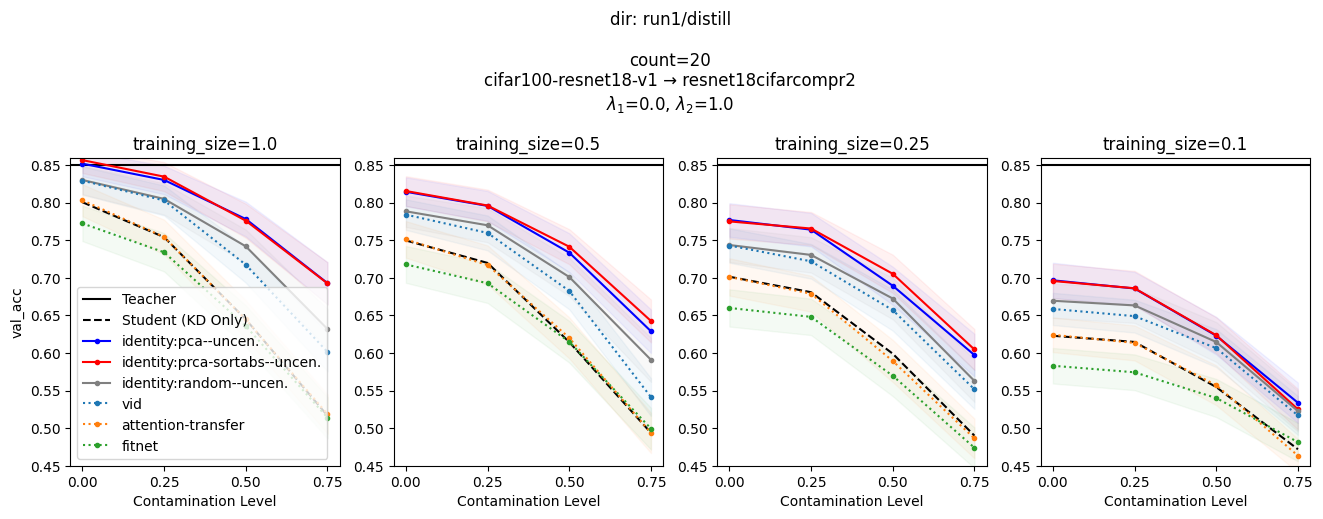

In [146]:
def ls(policy):
    if policy in ["fitnet", "attention-transfer", "vid"] :
        return ":"
    elif policy == "fitnetinvidbnrelu":
        return "-."
    else:
        return "-"
    
def marker(policy):
    return "."
    
    if "inner" in policy:
        return "."
    else:
        return None

def alias(policy):
    
    return policy \
        .replace("basis-identity", "identity") \
        .replace("uncentered", "uncen.")

    
    
def color(policy):
    if "pca" in policy:
        return "blue"
    elif "prca" in policy:
        return "red"
    elif "random" in policy:
        return "gray"
    elif policy == "fitnetinvidinner" or policy == "fitnetinvidbnrelu":
        return plt.gca().lines[-1].get_color()
    else:
        return None
    
def viz_distillation(
    teacher, student, policies, 
    arr_training_sizes,
    arr_contamination_levels,
    show_legend=True,
    include_baseline=True
):
        
    lambda_kd = 1.0
    lambda_task = 0.0

    
        

    col = "val_acc"
    
    ncols = len(arr_training_sizes)
    nrows = 1
    
    plt.figure(figsize=(4*ncols, 4*nrows))
    
    dirslug = "/".join(f"{EXPERIMENT_GROUP}".split("/")[-2:])
    
    for tix, training_size in enumerate(arr_training_sizes):
        plt.subplot(nrows, ncols, tix+1)
        plt.title(f"training_size={training_size}")
        
        for pix, policy in enumerate(policies):
            df = read_data(
                teacher=teacher,
                student=student,
                policy=policy,
                
                lambda_task=lambda_task,
                lambda_kd=lambda_kd,

                arr_training_sizes=[training_size],
                arr_contamination_levels=arr_contamination_levels,
                verbose=False
            )
            
            ticks = df["contamination_level"]

            
            # visualize baseline
            if pix == 0:

                plt.axhline(
                    df["teacher_acc"].values[-1],
                    ls="-",
                    color="k",
                    label="Teacher"
                )
                
                if include_baseline:
                    df_baseline = read_data_baseline(
                        teacher=teacher,
                        student=student,

                        lambda_task=lambda_task,
                        lambda_kd=lambda_kd,

                        training_size=training_size,
                        arr_contamination_levels=arr_contamination_levels,
                    )
                    plt.plot(
                        ticks,
                        df_baseline[col]["mean"],
                        ls="--",
                        color="k",
                        label="Student (KD Only)"
                    )
                plt.ylim(bottom=0.45, top=df["teacher_acc"].values[-1] + 0.01)
#                 plt.axhline(0.2, ls="--", color="lightgray")

            # here, we take the first value.
            # the query function already checks that the value is expected
            count = df[col]["count"].values[-1]

            mean = df[col]["mean"]
            stderr = df[col]["std"] / (count ** 0.5)

            plt.plot(
                ticks,
                mean,
                marker=".",
                label=alias(policy),
                ls=ls(policy),
                color=color(policy)
            )

            plt.fill_between(
                ticks,
                mean - stderr,
                mean + stderr,
                alpha=0.05,
                color=plt.gca().lines[-1].get_color()
            )

        plt.xlabel("Contamination Level")
        plt.xticks(ticks)
        if tix==0:
            plt.ylabel(col)

            plt.legend()

    plt.suptitle(
        "\n".join([
            f"dir: {dirslug}",
            "",
            f"count={count}",
            f"{teacher} → {student}",
            f"$\lambda_1$={lambda_task}, $\lambda_2$={lambda_kd}",
        ]),
        y=1.25,
    )

viz_distillation(
    teacher = "cifar100-resnet18-v1",
    student="resnet18cifarcompr2",
    arr_training_sizes=[1.0, 0.5, 0.25, 0.1],
    arr_contamination_levels=[0.0, 0.25, 0.5, 0.75],
    policies = [ 
        "basis-identity:pca--uncentered",
        "basis-identity:prca-sortabs--uncentered",
        "basis-identity:random--uncentered",
        "vid",
        "attention-transfer",
        "fitnet",
    ],
) 

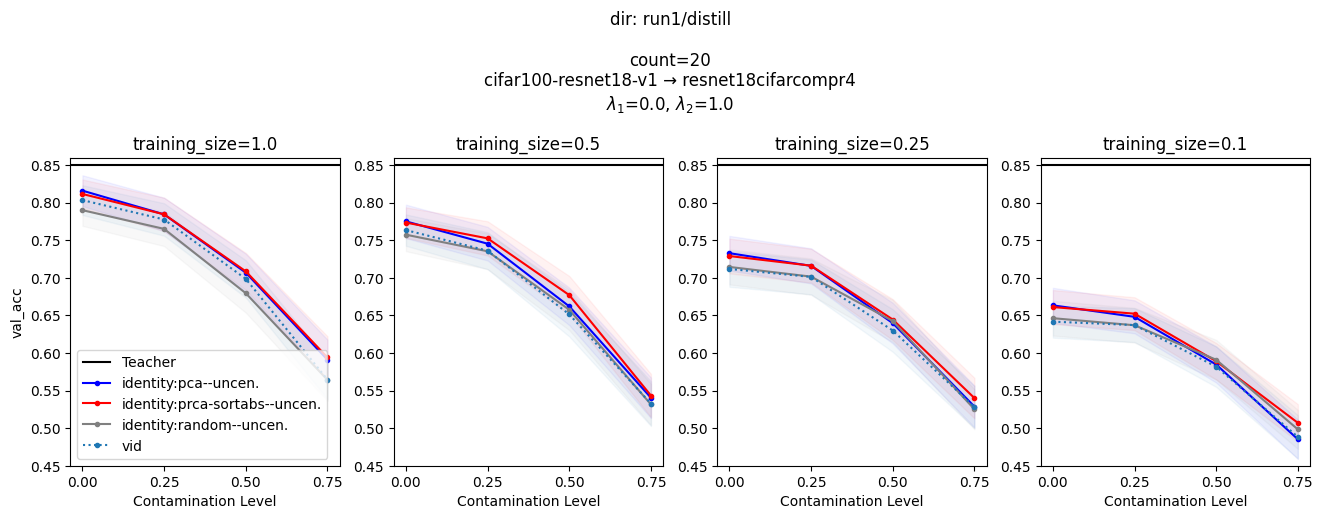

In [147]:
viz_distillation(
    teacher = "cifar100-resnet18-v1",
    student="resnet18cifarcompr4",
    arr_training_sizes=[1.0, 0.5, 0.25, 0.1],
    arr_contamination_levels=[0.0, 0.25, 0.5, 0.75],
    policies = [ 
        "basis-identity:pca--uncentered",
        "basis-identity:prca-sortabs--uncentered",
        "basis-identity:random--uncentered",
        "vid",
    ],
    include_baseline=False
) 

# Analysis Fitnet Level

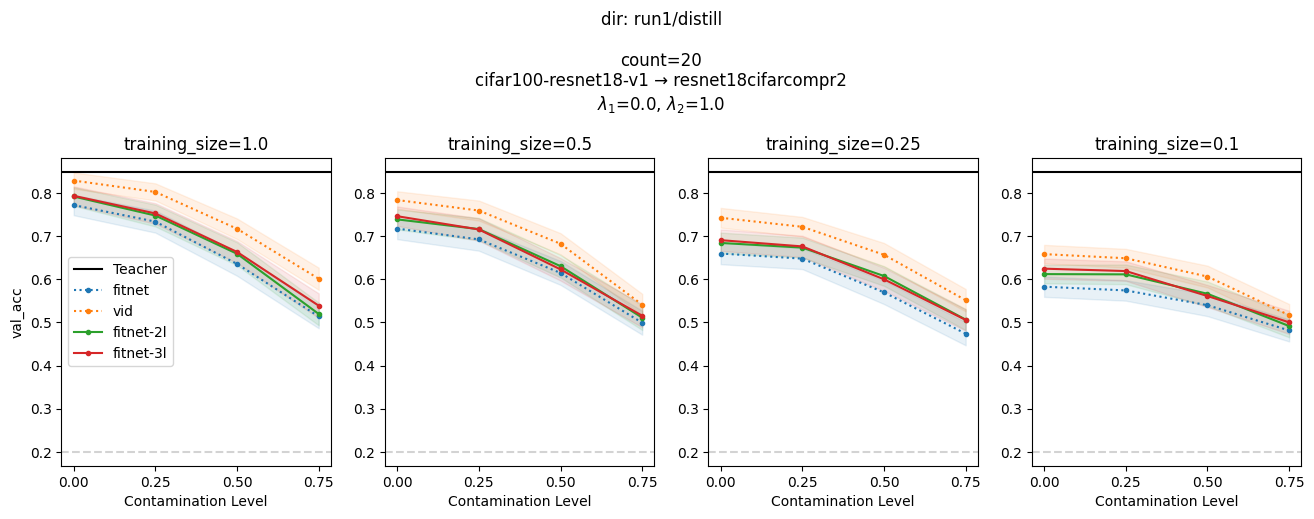

In [55]:
viz_distillation(
    teacher = "cifar100-resnet18-v1",
    student="resnet18cifarcompr2",
    arr_training_sizes=[1.0, 0.5, 0.25, 0.1],
    arr_contamination_levels=[0.0, 0.25, 0.5, 0.75],
    policies = [ 
        "fitnet",
        "vid",
        "fitnet-2l",
        "fitnet-3l",
    ],
) 

# Summary (to be written)

Setup:
$$
 (0.0) \ell_\text{task} + \lambda_2 \ell_\text{KD} + \lambda_3 \ell_\text{layer},
$$
$\lambda_2 = 1$ and $\lambda_3$ is set according to the hyperparameter optimization.

*Aims:* 
- investigate the benefit of using PRCA when varying these aspects:
    - the quality of data
    - the quantity of data

    - the size of the student model

*Conclusions:*
- When the quality of the training data drops, PRCA provides slightly better distilled models.Howoever, the difference between PRCA and PCA (the 2nd best) is very small
- We do not seem to see any difference between PRCA and PCA when we varying the quantity of the training data and the size of the student model.


*Further Refinement*: 
- Currently, $\lambda_3$ is chosen per policy using only the clean data. Perhaps, it might be better to tune it per policy and contamination level. 
  - The reason is that the higher contamination, the more layer regularization required
      - One way to see this is that running `pca` for those contamination values.
          - Expected: for each contamination value, the accuracy curve peaks at different $\lambda_3$.